## Energy Consumption — Exploratory Data Analysis

This analysis explores the distribution, temporal patterns, operating conditions, and relationships between energy consumption and the available variables. The findings are used to guide feature selection and forecasting decisions in later stages of the project.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from pandas.api.types import CategoricalDtype

In [3]:
df = pd.read_csv('../data/Steel_industry_data.csv')
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


### Energy Usage Distribution

In [4]:
# descriptive statistics
df['Usage_kWh'].describe()

count    35040.000000
mean        27.386892
std         33.444380
min          0.000000
25%          3.200000
50%          4.570000
75%         51.237500
max        157.180000
Name: Usage_kWh, dtype: float64

Findings: The mean Usage_kWh is considerably larger than the median, possibly indicating the influence of large values or outliers. The standard deviation is relatively large compared with the mean, indicating substantial variation in energy consumption. The large difference between the median and upper quartiles indicate significant variation in consumption. all these suggests that the distribution may be skewed to one side.
Things that may need further investigation: the minimum value being zero, is that a valid value or a value taken at a non-operating condition?, also, whether the high values are genuine values or are errors in data collection

Text(0.5, 1.0, 'Histogram of Energy Usage')

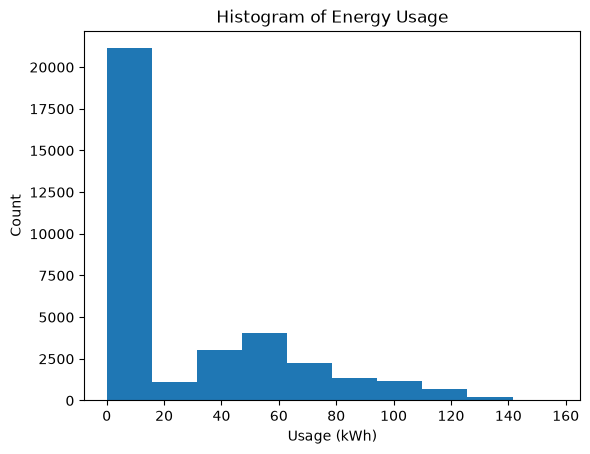

In [5]:
# plotting a histogram
fig, ax = plt.subplots()
ax.hist(df['Usage_kWh'])
ax.set_xlabel('Usage (kWh)')
ax.set_ylabel('Count')
ax.set_title('Histogram of Energy Usage')

Findings: The distribution is highly concentrated at low consumption levels and contains a second region of considerably higher consumption, followed bu a long upper tail. this suggests that different operating conditions may influence energy usage.

### Overall consumption over time

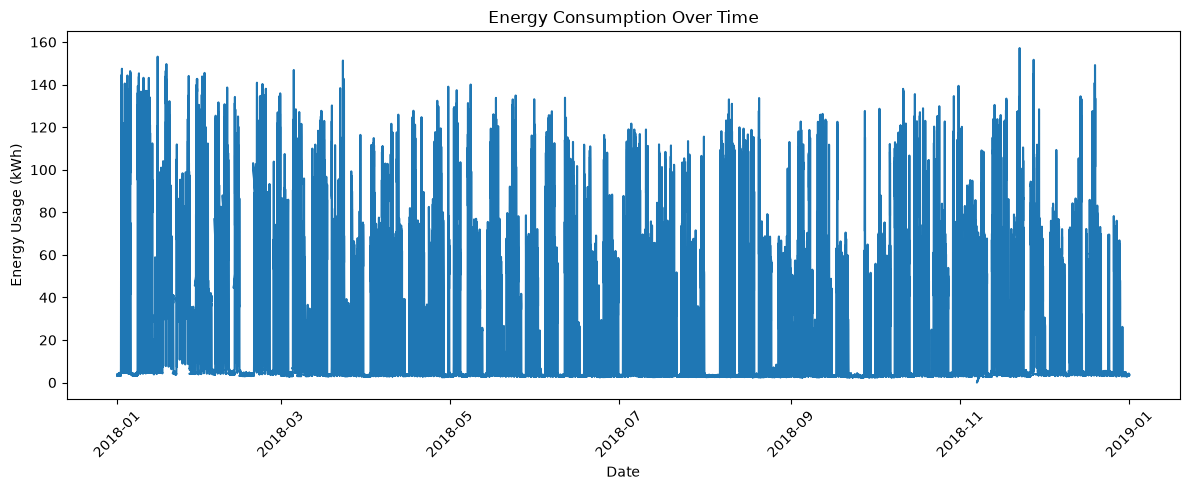

In [6]:
# converting date to datetime
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y %H:%M')

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df['date'], df['Usage_kWh'])

ax.set_xlabel('Date')
ax.set_ylabel('Energy Usage (kWh)')
ax.set_title('Energy Consumption Over Time')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Findings: Energy consumption varies considerably throughout the year, with repeated periods of higher and lower usage. This confirms the presence of temporal structure in the target variable and supports the use of time-based and historical consumption features for forecasting.

### Monthly Energy Usage


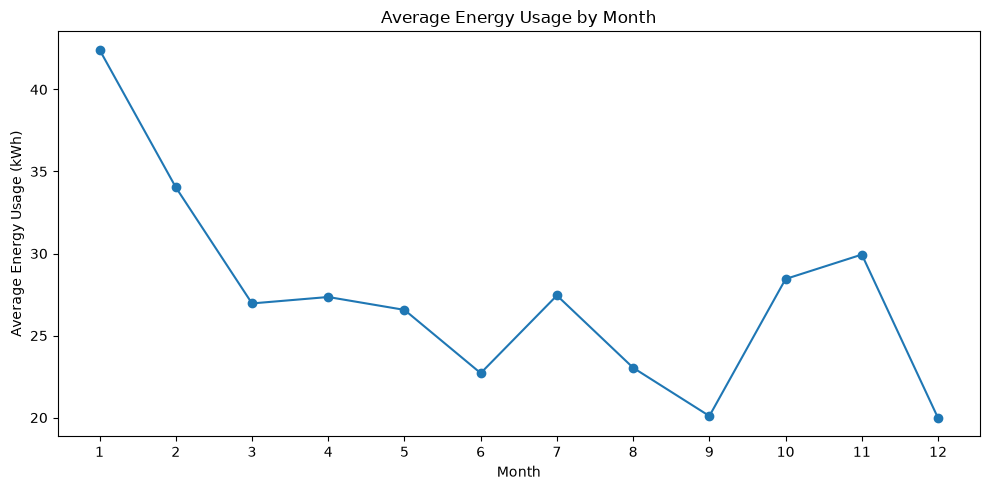

In [7]:
# calculating average energy usage for each month
monthly_usage = df.groupby(df['date'].dt.month)['Usage_kWh'].mean()

# plotting average monthly energy usage
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(monthly_usage.index, monthly_usage.values, marker='o')

ax.set_xlabel('Month')
ax.set_ylabel('Average Energy Usage (kWh)')
ax.set_title('Average Energy Usage by Month')
ax.set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

Findings: Average energy consumption varies considerably across the year. Usage is highest in January, followed by a substantial decline during the first quarter. Consumption then fluctuates at lower levels through the middle of the year before increasing again in October and November and declining sharply in December. The pattern does not follow a consistent seasonal trend, suggesting that monthly variation alone may not fully explain changes in energy consumption.

### Load Type

In [9]:
# frequency of each load type category
print(df['Load_Type'].value_counts())
print(df['Load_Type'].value_counts(normalize= True)*100)

Load_Type
Light_Load      18072
Medium_Load      9696
Maximum_Load     7272
Name: count, dtype: int64
Load_Type
Light_Load      51.575342
Medium_Load     27.671233
Maximum_Load    20.753425
Name: proportion, dtype: float64


Does the distribution of energy consumption differ between light, medium and maximum load conditions?

Text(0, 0.5, 'Energy usage')

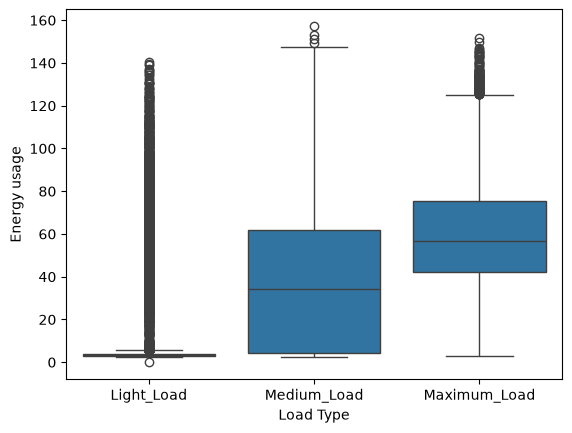

In [10]:
fig,ax = plt.subplots()
sns.boxplot(data =df, x = 'Load_Type', y = 'Usage_kWh')
ax.set_xlabel('Load Type')
ax.set_ylabel('Energy usage')

In [11]:
# desccriptive statistics for each load type
df.groupby('Load_Type')['Usage_kWh'].describe().sort_values(by = '50%')

,count,mean,std,min,25%,50%,75%,max
Load_Type,,,,,,,,
Light_Load,18072.0,8.626207,17.906245,0.00,2.9500,3.310,4.03,140.29
Medium_Load,9696.0,38.445394,35.220166,2.52,4.4200,34.435,61.70,157.18
Maximum_Load,7272.0,59.265314,29.749700,2.92,42.0025,56.630,75.31,151.67


Findings: the median of the groups increases from light to medium to maximum load which could mean that higher load type categories are associated with higher energy usage, however values within each group overlap considerably, making the relationship less clear. There is also a large number of 'outliers' in the light load group because values in the group seriously exceed the max value calculated by Q3+1.5IQR. This requires further investigation, as it could be due to mislabelling or because factors other than load type also influence energy usage.

### Time of Day

Text(0.5, 1.0, 'Usage against Time')

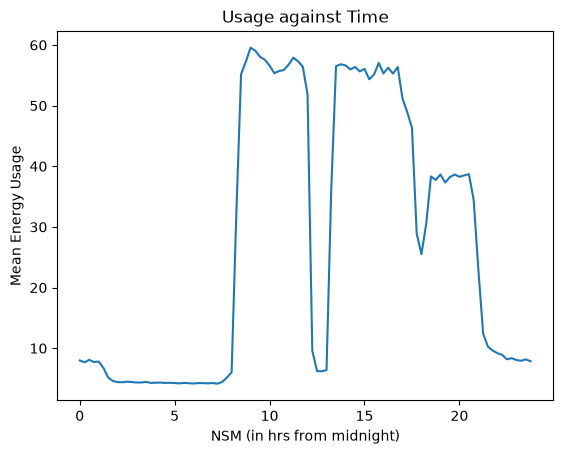

In [12]:
# plot of usage against time
df['NSM_hours'] = df['NSM'] / 3600
mean_nsm = df.groupby('NSM_hours')['Usage_kWh'].mean()
fig,ax = plt.subplots()
ax.plot(mean_nsm)
ax.set_xlabel('NSM (in hrs from midnight)')
ax.set_ylabel('Mean Energy Usage')
ax.set_title('Usage against Time')

Findings: Energy consumption varies substantially throughout the day, with distinct periods of higher and lower usage. This indicates that time of day is an important factor in the consumption pattern and motivates the inclusion of temporal features in the forecasting model.

### Weekday vs Weekend

Does the distribution of energy consumption differ between weekdays and weekends?

In [13]:
print(df['WeekStatus'].value_counts())
print(df['WeekStatus'].value_counts(normalize = True)*100)

WeekStatus
Weekday    25056
Weekend     9984
Name: count, dtype: int64
WeekStatus
Weekday    71.506849
Weekend    28.493151
Name: proportion, dtype: float64


Text(0, 0.5, 'Energy usage')

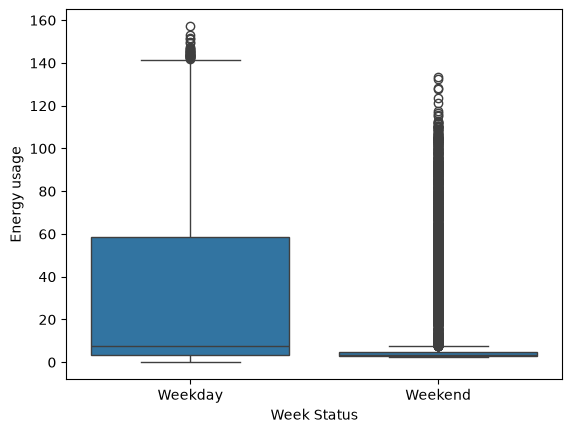

In [14]:
fig,ax = plt.subplots()
sns.boxplot(data = df, x = 'WeekStatus', y= 'Usage_kWh')
ax.set_xlabel('Week Status')
ax.set_ylabel('Energy usage')

Text(0.5, 1.0, 'Average Energy Usage by Time of Day and Week Status')

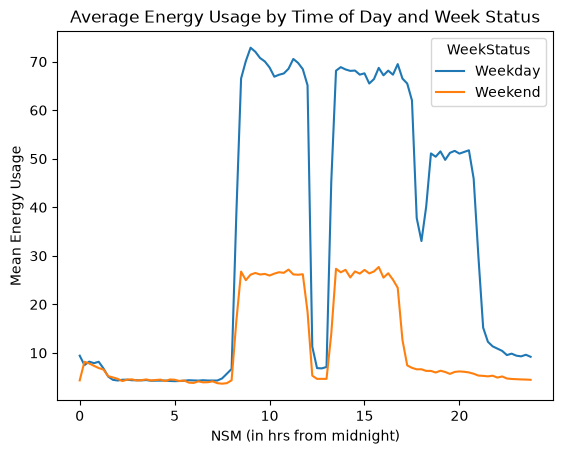

In [15]:
# weekday vs weekend plot usage vs NSM
fig,ax = plt.subplots()
sns.lineplot(data = df, x ='NSM_hours', y = 'Usage_kWh', hue = 'WeekStatus', ax=ax, errorbar = None)
ax.set_xlabel('NSM (in hrs from midnight)')
ax.set_ylabel('Mean Energy Usage')
ax.set_title('Average Energy Usage by Time of Day and Week Status')

Findings: The average daily consumption profile differs significantly between weekdays and weekends. Both groups show similar changes in consumption during similar times, however weekday consumption is significantly higher during active periods. the similar timing but different consumption levels may indicate that the facility follows an operating schedule that depends on whether it is weekend or a weekday.

### Day of Week

In [16]:
df['Day_of_week'].value_counts()

Day_of_week
Monday       5088
Tuesday      4992
Wednesday    4992
Thursday     4992
Friday       4992
Saturday     4992
Sunday       4992
Name: count, dtype: int64

In [17]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
cat_type = CategoricalDtype(categories= order, ordered= True)
df['Day_of_week'] = df['Day_of_week'].astype(cat_type)

Text(0, 0.5, 'Energy Usage')

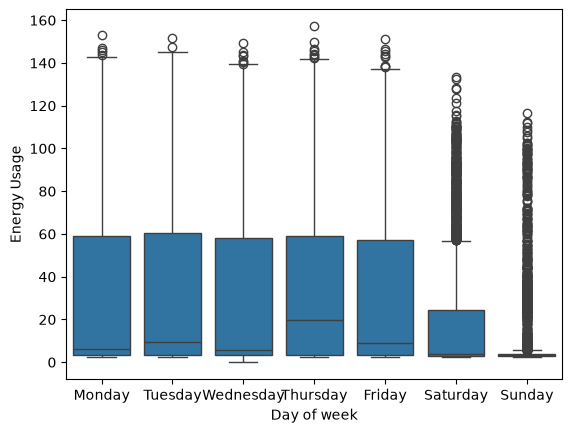

In [18]:
fig,ax = plt.subplots()
sns.boxplot(data = df, x = 'Day_of_week', y = 'Usage_kWh', ax = ax)
ax.set_xlabel('Day of week')
ax.set_ylabel('Energy Usage')

Text(0.5, 1.0, 'Average Energy Usage by Time of Day and Day of Week')

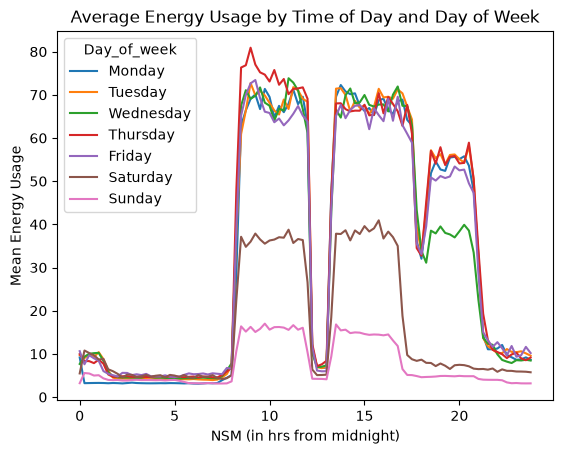

In [19]:
fig,ax = plt.subplots()
sns.lineplot(data = df, x ='NSM_hours', y = 'Usage_kWh', hue = 'Day_of_week', ax=ax, errorbar = None)
ax.set_xlabel('NSM (in hrs from midnight)')
ax.set_ylabel('Mean Energy Usage')
ax.set_title('Average Energy Usage by Time of Day and Day of Week')

Findings: weekdays follow a common operating pattern, and while Saturday follows a similar pattern, it has a lower magnitude with Sunday being even lower. Thursday has a slightly higher peak to the rest of the weekdays. Lastly, the day of the week appears to affect consumption intensity more than the overall timing of the operating schedule.

### Historical Energy Usage

In [22]:
lags = [1, 2, 4, 96, 672]
lag_correlations = {
    f'Lag {lag}': df['Usage_kWh'].corr(df['Usage_kWh'].shift(lag))
    for lag in lags
}

lag_correlations = pd.Series(lag_correlations)

lag_correlations

Lag 1      0.913044
Lag 2      0.835967
Lag 4      0.687981
Lag 96     0.606296
Lag 672    0.676703
dtype: float64

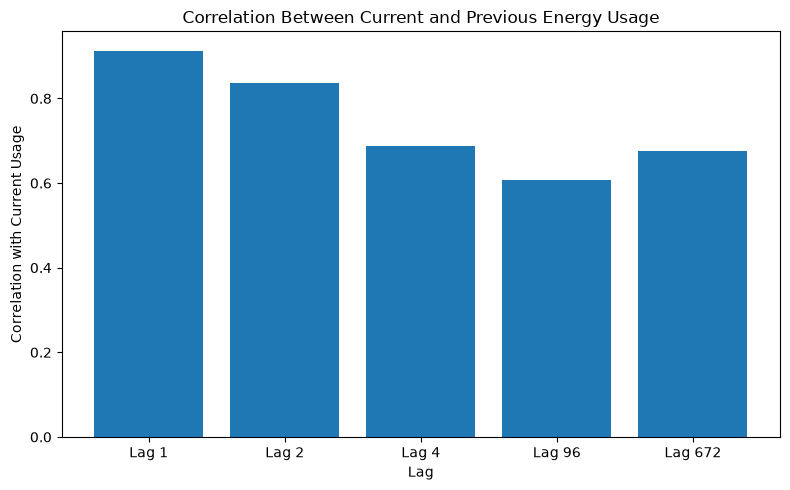

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(lag_correlations.index, lag_correlations.values)

ax.set_xlabel('Lag')
ax.set_ylabel('Correlation with Current Usage')
ax.set_title('Correlation Between Current and Previous Energy Usage')

plt.tight_layout()
plt.show()

Findings: Energy consumption shows strong short-term dependence, with the correlation decreasing from 0.913 at 15 minutes to 0.688 at one hour. Meaningful correlations are also observed at one day (0.606) and one week (0.677), indicating that consumption patterns extend beyond the most recent observations. These results support the use of historical consumption at short-term, daily, and weekly intervals as forecasting features.

### Electrical (Numerical) Variables

In [24]:
# correlation of numerical features
numerical = df[['Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
    'Leading_Current_Reactive_Power_kVarh','CO2(tCO2)','Lagging_Current_Power_Factor',
    'Leading_Current_Power_Factor','NSM']]
correlation = numerical.corr()
correlation

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
Usage_kWh,1.000000,0.896150,-0.324922,0.988180,0.385960,0.353566,0.234610
Lagging_Current_Reactive.Power_kVarh,0.896150,1.000000,-0.405142,0.886948,0.144534,0.407716,0.082662
Leading_Current_Reactive_Power_kVarh,-0.324922,-0.405142,1.000000,-0.332777,0.526770,-0.944039,0.371605
CO2(tCO2),0.988180,0.886948,-0.332777,1.000000,0.379605,0.360019,0.231726
Lagging_Current_Power_Factor,0.385960,0.144534,0.526770,0.379605,1.000000,-0.519967,0.565270
Leading_Current_Power_Factor,0.353566,0.407716,-0.944039,0.360019,-0.519967,1.000000,-0.360563
NSM,0.234610,0.082662,0.371605,0.231726,0.565270,-0.360563,1.000000


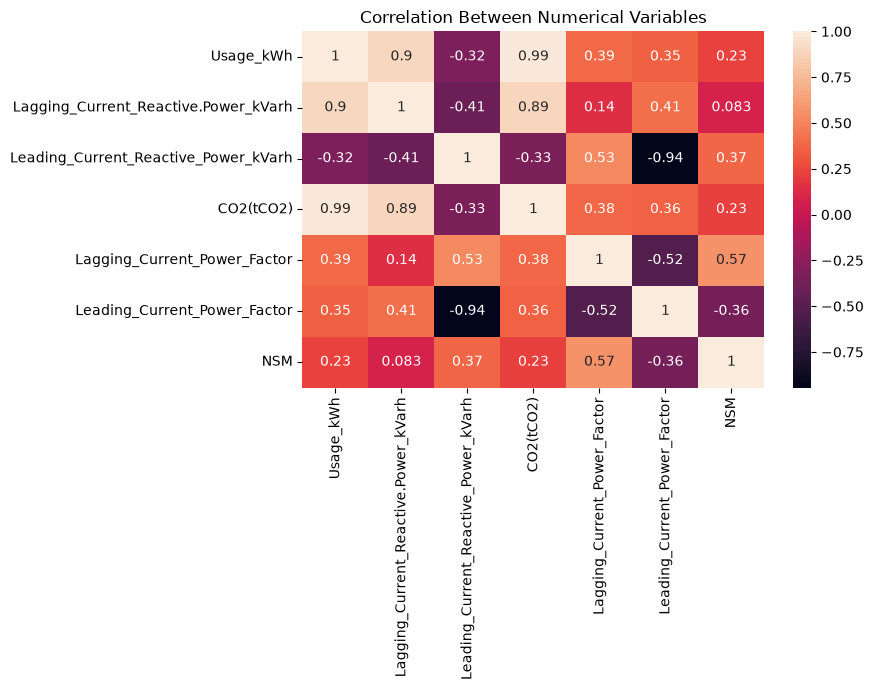

In [25]:
fig, ax = plt.subplots(figsize=(9, 7))

sns.heatmap(correlation, annot=True, ax=ax)

ax.set_title('Correlation Between Numerical Variables')

plt.tight_layout()
plt.show()

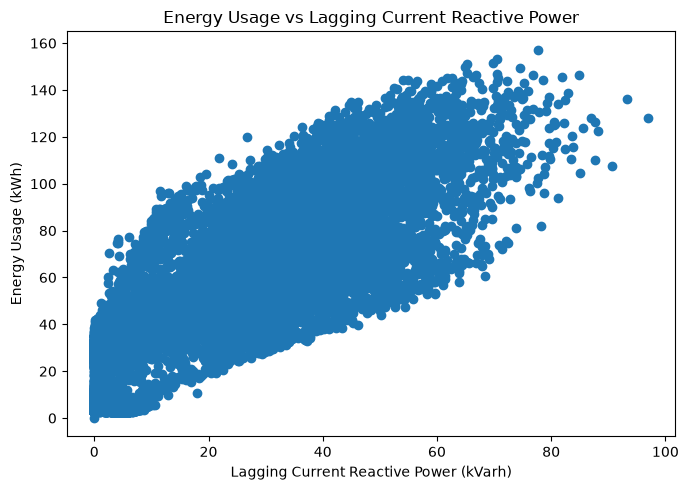

In [26]:
# Correlation between Energy Usage and Lagging Current Reactive Power
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    df['Lagging_Current_Reactive.Power_kVarh'],
    df['Usage_kWh']
)

ax.set_xlabel('Lagging Current Reactive Power (kVarh)')
ax.set_ylabel('Energy Usage (kWh)')
ax.set_title('Energy Usage vs Lagging Current Reactive Power')

plt.tight_layout()
plt.show()

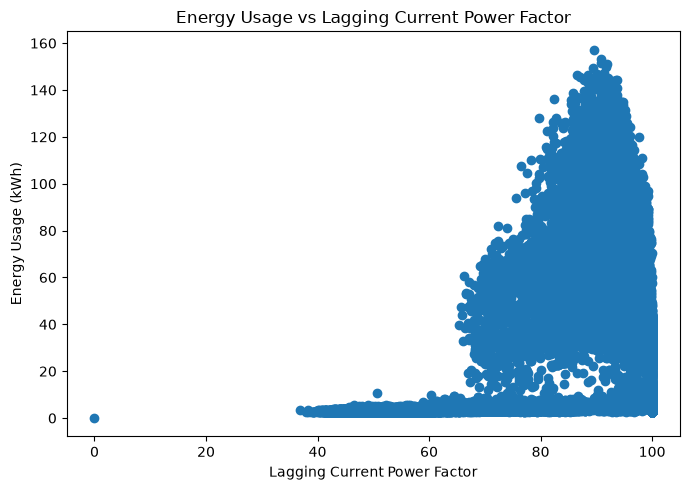

In [27]:
# Correlation between Energy Usage and Lagging Current Power Factor
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    df['Lagging_Current_Power_Factor'],
    df['Usage_kWh']
)

ax.set_xlabel('Lagging Current Power Factor')
ax.set_ylabel('Energy Usage (kWh)')
ax.set_title('Energy Usage vs Lagging Current Power Factor')

plt.tight_layout()
plt.show()

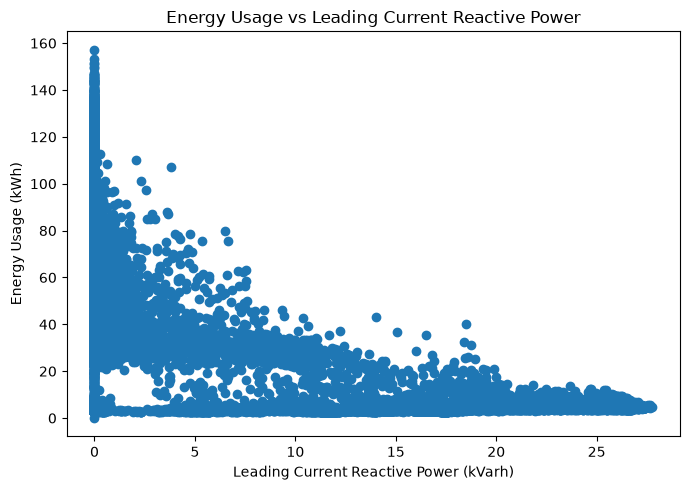

In [28]:
# Correlation between Energy Usage and Leading Current Reactive Power
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    df['Leading_Current_Reactive_Power_kVarh'],
    df['Usage_kWh']
)

ax.set_xlabel('Leading Current Reactive Power (kVarh)')
ax.set_ylabel('Energy Usage (kWh)')
ax.set_title('Energy Usage vs Leading Current Reactive Power')

plt.tight_layout()
plt.show()

Findings: The numerical variables show varying degrees of association with energy consumption. CO₂ has an exceptionally strong relationship with Usage_kWh, while several electrical variables also show notable associations. The strong relationships between some predictors suggest potential redundancy among the electrical variables. These relationships will be considered when selecting features for forecasting, particularly where variables may not be available at prediction time or may contain information about contemporaneous energy consumption.

### Other Analysis

#### Zero Energy Usage

In [176]:
df.query('Usage_kWh == 0')

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,NSM_hrs
29855,07/11/2018 00:00,0.0,0.0,0.0,0.0,0.0,0.0,0,Weekday,Wednesday,Light_Load,0.0


#### Highest Energy Usage Observations

In [179]:
highest_kwh = df.sort_values(by = 'Usage_kWh', ascending = False)
highest_kwh.head(10)

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,NSM_hrs
31238,22/11/2018 09:45,157.18,77.72,0.0,0.07,89.64,100.0,35100,Weekday,Thursday,Medium_Load,9.75
1398,15/01/2018 13:45,153.14,70.45,0.0,0.07,90.85,100.0,49500,Weekday,Monday,Medium_Load,13.75
31723,27/11/2018 11:00,151.67,69.73,0.0,0.07,90.86,100.0,39600,Weekday,Tuesday,Maximum_Load,11.00
7812,23/03/2018 09:15,151.31,65.20,0.0,0.07,91.84,100.0,33300,Weekday,Friday,Medium_Load,9.25
1701,18/01/2018 17:30,149.65,64.87,0.0,0.07,91.75,100.0,63000,Weekday,Thursday,Maximum_Load,17.50
33848,19/12/2018 14:15,149.18,74.56,0.0,0.07,89.45,100.0,51300,Weekday,Wednesday,Medium_Load,14.25
162,02/01/2018 16:45,147.46,65.27,0.0,0.00,91.44,100.0,60300,Weekday,Tuesday,Medium_Load,16.75
6111,05/03/2018 16:00,146.88,70.49,0.0,0.07,90.16,100.0,57600,Weekday,Monday,Maximum_Load,16.00
1679,18/01/2018 12:00,146.48,84.89,0.0,0.07,86.52,100.0,43200,Weekday,Thursday,Maximum_Load,12.00
447,05/01/2018 16:00,146.34,66.92,0.0,0.07,90.94,100.0,57600,Weekday,Friday,Medium_Load,16.00


Text(0.5, 1.0, 'Correlation between Energy Usage and CO2 Emission')

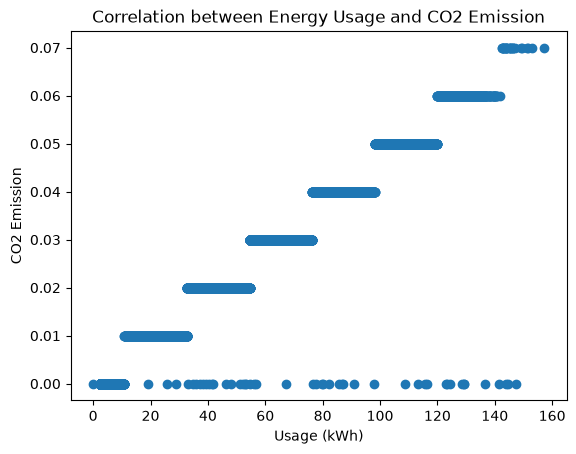

In [181]:
fig, ax = plt.subplots()
ax.scatter(df['Usage_kWh'], df['CO2(tCO2)'])
ax.set_xlabel('Usage (kWh)')
ax.set_ylabel('CO2 Emission')
ax.set_title('Correlation between Energy Usage and CO2 Emission')

Findings: The dataset contains one zero-usage observation, with the associated electrical measurements also recorded as zero. The observation is retained because there is insufficient evidence to determine whether it represents a genuine non-operating period or a recording condition. The highest energy usage observations occur alongside plausible electrical measurements, so there is no immediate evidence that they are erroneous. CO₂ emissions show an extremely strong relationship with energy usage, increasing in discrete steps as consumption increases. CO₂ was therefore excluded from the forecasting features because its availability at prediction time is uncertain and its relationship with contemporaneous energy consumption could introduce information leakage.

### Summary

The EDA shows that energy consumption has substantial temporal structure, with clear variation across time of day, day of week, weekday/weekend status, and month. Current consumption also has strong relationships with previous consumption at short-term, daily, and weekly intervals. The electrical variables show varying degrees of association with energy usage, while the strong relationship between CO₂ and consumption raises concerns about its suitability as a forecasting predictor. These findings support a forecasting approach that combines temporal information with historical energy consumption.